# 統合消費電流測定解析 v2 (Probe Request版)

nrf_power_test_all.ino (v2: ピン修正・SoftwareSerial修正済み) で全フェーズを一括測定したデータを解析する。

**フェーズ構成**:
- フェーズ2: WiFiスキャン (3/5/10秒 × 各5回)
- フェーズ3: カメラ (60秒録画 × 3回)
- フェーズ4: SD書き込み (B:一括 × 10回, C:毎秒60秒 × 3回)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Meiryo'
plt.rcParams['axes.unicode_minus'] = False

CSV_FILE = 'dist/current_log_all_v2-2.csv'

# v2: 3/5/10秒 x 5回 = 15回, カメラ 3回
SCAN_PATTERNS_MS = [3000, 5000, 10000]
REPS_PER_PATTERN = 5
CAMERA_REPS = 3

In [2]:
# ============================================================
# データ読み込み
# ============================================================
df = pd.read_csv(CSV_FILE)
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# 先頭ノイズ除去
valid_idx = df[df['Current (mA)'] > -10].index[0]
df = df.iloc[valid_idx:].reset_index(drop=True)

df['elapsed_s'] = (df['Timestamp'] - df['Timestamp'].iloc[0]).dt.total_seconds()
current = df['Current (mA)'].values
timestamps = df['elapsed_s'].values

print(f'データ件数: {len(df)}')
print(f'時間範囲: {df["Timestamp"].iloc[0]} ~ {df["Timestamp"].iloc[-1]}')
print(f'全体時間: {df["elapsed_s"].iloc[-1]/60:.1f} 分')

データ件数: 13291
時間範囲: 2026-03-19 19:29:43.476710 ~ 2026-03-19 19:41:16.571215
全体時間: 11.6 分


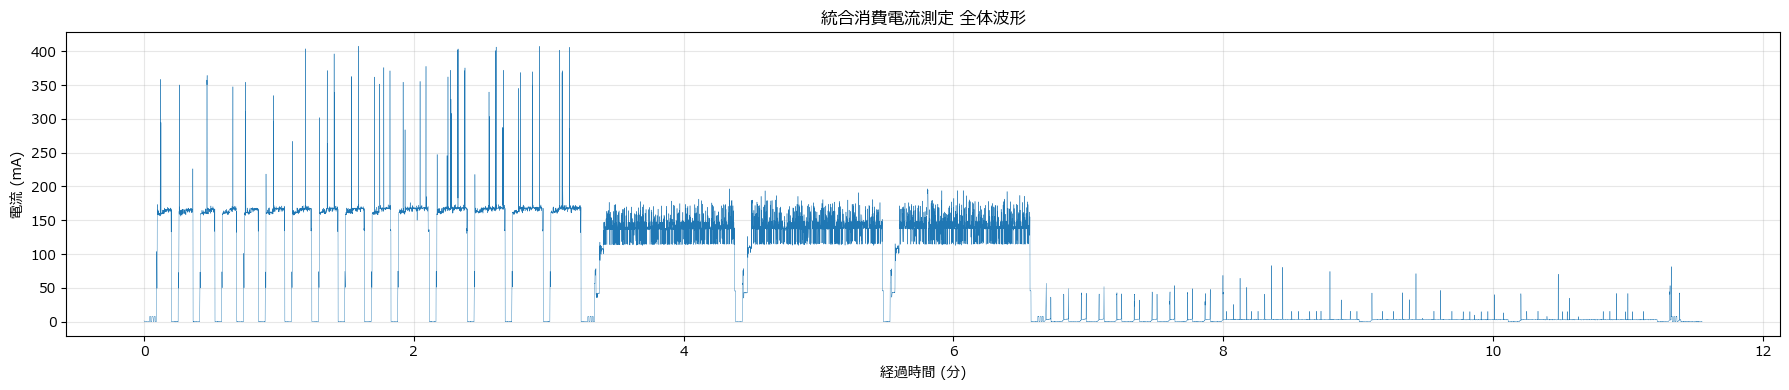

In [3]:
# ============================================================
# 全体の電流波形
# ============================================================
fig, ax = plt.subplots(figsize=(18, 4))
ax.plot(df['elapsed_s']/60, df['Current (mA)'], linewidth=0.3)
ax.set_xlabel('経過時間 (分)')
ax.set_ylabel('電流 (mA)')
ax.set_title('統合消費電流測定 全体波形')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
# ============================================================
# ON区間検出 → WiFi / カメラに分割
# ============================================================
is_on = current > 30
transitions = np.diff(is_on.astype(int))
on_starts = np.where(transitions == 1)[0] + 1
on_ends = np.where(transitions == -1)[0] + 1
if is_on[0]: on_starts = np.insert(on_starts, 0, 0)
if is_on[-1]: on_ends = np.append(on_ends, len(is_on))
n = min(len(on_starts), len(on_ends))

valid_on = []
for i in range(n):
    s, e = on_starts[i], on_ends[i]
    dur = timestamps[min(e, len(timestamps)-1)] - timestamps[s]
    if dur >= 1.0:
        valid_on.append((s, e))

total_wifi = len(SCAN_PATTERNS_MS) * REPS_PER_PATTERN
wifi_intervals = valid_on[:total_wifi]
camera_intervals = valid_on[total_wifi:total_wifi + CAMERA_REPS]

print(f'ON区間: {len(valid_on)}個')
print(f'WiFi: {len(wifi_intervals)}個 (期待値: {total_wifi})')
print(f'カメラ: {len(camera_intervals)}個 (期待値: {CAMERA_REPS})')

ON区間: 18個
WiFi: 15個 (期待値: 15)
カメラ: 3個 (期待値: 3)


In [5]:
# ============================================================
# (フェーズ1: 待機 - スキップ、既に測定済み)
# ============================================================
print('フェーズ1: スキップ (別途測定済み)')

フェーズ1: スキップ (別途測定済み)


In [6]:
# ============================================================
# フェーズ2: WiFiスキャン解析
# ============================================================
# WiFi区間の範囲からベースライン算出
wifi_start_t = timestamps[wifi_intervals[0][0]]
wifi_end_t = timestamps[wifi_intervals[-1][1]]
wifi_on_idx = set()
for s, e in wifi_intervals:
    wifi_on_idx.update(range(s, e))
wifi_range = (timestamps >= wifi_start_t) & (timestamps <= wifi_end_t)
wifi_range_idx = set(np.where(wifi_range)[0])
wifi_off_idx = wifi_range_idx - wifi_on_idx
wifi_off_mask = df.index.isin(wifi_off_idx)
wifi_baseline = df.loc[wifi_off_mask, 'Current (mA)'].mean()
print(f'WiFiベースライン (OFF区間): {wifi_baseline:.2f} mA')

# パターン別集計
wifi_results = []
for i, (s, e) in enumerate(wifi_intervals):
    seg = current[s:e]
    dur = timestamps[min(e, len(timestamps)-1)] - timestamps[s]
    pidx = i // REPS_PER_PATTERN
    wifi_results.append({
        'scan_ms': SCAN_PATTERNS_MS[pidx] if pidx < len(SCAN_PATTERNS_MS) else -1,
        'rep': i % REPS_PER_PATTERN + 1,
        'duration_s': dur,
        'mean_mA': seg.mean() - wifi_baseline,
        'peak_mA': seg.max() - wifi_baseline,
    })

df_wifi = pd.DataFrame(wifi_results)
summary_wifi = df_wifi.groupby('scan_ms').agg(
    回数=('mean_mA', 'count'),
    ON区間秒=('duration_s', 'mean'),
    平均電流=('mean_mA', 'mean'),
    標準偏差=('mean_mA', 'std'),
    ピーク=('peak_mA', 'max'),
).reset_index()
summary_wifi.columns = ['スキャン(ms)', '回数', 'ON区間(秒)', '平均電流(mA)', '標準偏差(mA)', 'ピーク(mA)']

print('\n=== WiFiスキャン パターン別集計 (ベースライン差し引き) ===')
print(summary_wifi.to_string(index=False))

WiFiベースライン (OFF区間): 0.23 mA

=== WiFiスキャン パターン別集計 (ベースライン差し引き) ===
 スキャン(ms)  回数   ON区間(秒)   平均電流(mA)  標準偏差(mA)    ピーク(mA)
     3000   5  6.646954 161.186903  1.292230 364.172323
     5000   5  8.764483 164.134040  1.417987 407.472323
    10000   5 13.883182 167.243934  1.587469 407.272323


In [7]:
# ============================================================
# フェーズ3: カメラ解析
# ============================================================
# カメラ区間のベースライン
cam_start_t = timestamps[camera_intervals[0][0]]
cam_end_t = timestamps[camera_intervals[-1][1]]
cam_on_idx = set()
for s, e in camera_intervals:
    cam_on_idx.update(range(s, e))
cam_range = (timestamps >= cam_start_t) & (timestamps <= cam_end_t)
cam_range_idx = set(np.where(cam_range)[0])
cam_off_idx = cam_range_idx - cam_on_idx
cam_off_mask = df.index.isin(cam_off_idx)
cam_baseline = df.loc[cam_off_mask, 'Current (mA)'].mean()
print(f'カメラベースライン (OFF区間): {cam_baseline:.2f} mA')

camera_results = []
for i, (s, e) in enumerate(camera_intervals):
    seg = current[s:e]
    dur = timestamps[min(e, len(timestamps)-1)] - timestamps[s]
    camera_results.append({
        'rep': i + 1,
        'duration_s': dur,
        'mean_mA': seg.mean() - cam_baseline,
        'peak_mA': seg.max() - cam_baseline,
    })

df_camera = pd.DataFrame(camera_results)
print('\n=== カメラ録画 (ベースライン差し引き) ===')
print(df_camera.to_string(index=False))
print(f'\n平均電流: {df_camera["mean_mA"].mean():.1f} mA')
print(f'ピーク電流: {df_camera["peak_mA"].max():.1f} mA')

カメラベースライン (OFF区間): 0.44 mA

=== カメラ録画 (ベースライン差し引き) ===
 rep  duration_s    mean_mA    peak_mA
   1   62.713838 133.831735 196.064103
   2   62.714079 135.474534 193.164103
   3   62.662754 136.215726 196.064103

平均電流: 135.2 mA
ピーク電流: 196.1 mA


In [8]:
# ============================================================
# フェーズ4: SD書き込み解析
# ============================================================
if camera_intervals:
    last_cam_end_t = timestamps[camera_intervals[-1][1]]
    post_cam = df[(df['elapsed_s'] > last_cam_end_t + 2) & (df['Current (mA)'] > 3)]
    if len(post_cam) > 0:
        p4_start = post_cam['elapsed_s'].iloc[0] + 3
    else:
        p4_start = last_cam_end_t + 8
else:
    p4_start = timestamps[-1] - 300

p4_candidates = df[(df['elapsed_s'] > p4_start + 60) & (df['Current (mA)'] > 3)]
if len(p4_candidates) > 0:
    p4_end = p4_candidates['elapsed_s'].max() + 5
else:
    p4_end = timestamps[-1]

p4_data = df[(df['elapsed_s'] >= p4_start) & (df['elapsed_s'] < p4_end)]
print(f'フェーズ4区間: {p4_start:.0f}~{p4_end:.0f}秒 ({(p4_end-p4_start)/60:.1f}分)')
print(f'データ件数: {len(p4_data)}')

if len(p4_data) == 0:
    print('フェーズ4のデータが見つかりません')
    pb_data = pd.DataFrame()
    pc_data = pd.DataFrame()
    pb_end = p4_start
else:
    # B/C境界: パターンBのOFF区間はベースライン~0mA、パターンCは~1.2mA
    # 10秒ウィンドウのベースライン(<5mA)平均が連続して1.0mA超えになる地点を検出
    pb_end = None
    for offset in range(20, 200, 5):
        t0 = p4_start + offset
        t1 = t0 + 10  # 10秒ウィンドウ
        seg = df[(df['elapsed_s'] >= t0) & (df['elapsed_s'] < t1)]
        low = seg[seg['Current (mA)'] < 5]
        if len(low) > 20 and low['Current (mA)'].mean() > 1.0:
            # 次のウィンドウも確認（偽検出防止）
            seg2 = df[(df['elapsed_s'] >= t1) & (df['elapsed_s'] < t1 + 10)]
            low2 = seg2[seg2['Current (mA)'] < 5]
            if len(low2) > 20 and low2['Current (mA)'].mean() > 0.8:
                pb_end = t0
                break

    if pb_end is None:
        pb_end = p4_start + 76
        print(f'B/C境界を自動検出できず、フォールバック値を使用: {pb_end:.0f}秒')

    pb_data = df[(df['elapsed_s'] >= p4_start) & (df['elapsed_s'] < pb_end)]
    pc_data = df[(df['elapsed_s'] >= pb_end) & (df['elapsed_s'] < p4_end)]

    print(f'\nパターンB区間: {p4_start:.0f}~{pb_end:.0f}秒 ({(pb_end-p4_start):.0f}秒)')
    if len(pb_data) > 0:
        print(f'  全体平均電流: {pb_data["Current (mA)"].mean():.2f} mA')
        print(f'  最大電流: {pb_data["Current (mA)"].max():.1f} mA')
        pb_low = pb_data[pb_data['Current (mA)'] < 3]
        pb_baseline = pb_low['Current (mA)'].mean() if len(pb_low) > 0 else 0
        print(f'  ベースライン (SD OFF): {pb_baseline:.2f} mA')

    print(f'\nパターンC区間: {pb_end:.0f}~{p4_end:.0f}秒 ({(p4_end-pb_end):.0f}秒)')
    if len(pc_data) > 0:
        print(f'  全体平均電流: {pc_data["Current (mA)"].mean():.2f} mA')
        print(f'  最大電流: {pc_data["Current (mA)"].max():.1f} mA')
        pc_low = pc_data[pc_data['Current (mA)'] < 5]
        pc_baseline = pc_low['Current (mA)'].mean() if len(pc_low) > 0 else 0
        print(f'  ベースライン (SD ON アイドル): {pc_baseline:.2f} mA')

    print('\n--- パターンC 各サイクル ---')
    for i in range(3):
        t0 = pb_end + i * 65
        t1 = t0 + 60
        seg = df[(df['elapsed_s'] >= t0) & (df['elapsed_s'] < t1)]
        off_seg = df[(df['elapsed_s'] >= t1) & (df['elapsed_s'] < t1 + 5)]
        if len(seg) > 0:
            seg_low = seg[seg['Current (mA)'] < 5]
            seg_baseline = seg_low['Current (mA)'].mean() if len(seg_low) > 0 else 0
            print(f'  C-{i+1} ON (60秒): mean={seg["Current (mA)"].mean():.2f}mA, baseline={seg_baseline:.2f}mA, max={seg["Current (mA)"].max():.1f}mA')
        if len(off_seg) > 0:
            print(f'  C-{i+1} OFF (5秒):  mean={off_seg["Current (mA)"].mean():.2f}mA')

    print(f'\n=== SD方式比較 ===')
    if len(pb_data) > 0:
        print(f'パターンB (1分1回ON) サイクル平均: {pb_data["Current (mA)"].mean():.2f} mA')
    print(f'パターンC (常時ON)   サイクル平均: {pc_data["Current (mA)"].mean():.2f} mA')
    if len(pc_data) > 0:
        print(f'SD ON アイドル電流: {pc_baseline:.2f} mA')

フェーズ4区間: 401~688秒 (4.8分)
データ件数: 5543

パターンB区間: 401~456秒 (55秒)
  全体平均電流: 2.58 mA
  最大電流: 56.8 mA
  ベースライン (SD OFF): 0.31 mA

パターンC区間: 456~688秒 (233秒)
  全体平均電流: 3.21 mA
  最大電流: 82.9 mA
  ベースライン (SD ON アイドル): 2.53 mA

--- パターンC 各サイクル ---
  C-1 ON (60秒): mean=3.45mA, baseline=2.30mA, max=82.9mA
  C-1 OFF (5秒):  mean=3.38mA
  C-2 ON (60秒): mean=3.41mA, baseline=2.96mA, max=74.2mA
  C-2 OFF (5秒):  mean=3.37mA
  C-3 ON (60秒): mean=2.98mA, baseline=2.59mA, max=70.2mA
  C-3 OFF (5秒):  mean=2.89mA

=== SD方式比較 ===
パターンB (1分1回ON) サイクル平均: 2.58 mA
パターンC (常時ON)   サイクル平均: 3.21 mA
SD ON アイドル電流: 2.53 mA


In [9]:
# ============================================================
# SD方式の正確な比較 (電流積分ベース)
# ============================================================

dt = df['elapsed_s'].diff().median()  # サンプリング間隔 (秒)

# --- パターンB: 区間全体を積分して10サイクルで割る ---
pb_current = pb_data['Current (mA)'].values
pb_total_charge = pb_current.sum() * dt  # 全区間の電流累積 (mA・秒)
pb_total_time = pb_data['elapsed_s'].iloc[-1] - pb_data['elapsed_s'].iloc[0]
pb_num_cycles = 10
pb_charge_per_cycle = pb_total_charge / pb_num_cycles  # 1サイクルあたりの累積
pb_per_min = pb_charge_per_cycle / 60.0  # 1分あたりの平均電流

print('--- パターンB (1分1回ON方式) ---')
print(f'  区間: {pb_total_time:.1f}秒, {pb_num_cycles}サイクル')
print(f'  全区間の電流累積: {pb_total_charge:.1f} mA・秒')
print(f'  1サイクルあたり: {pb_charge_per_cycle:.2f} mA・秒')
print(f'  1分あたり平均電流: {pb_per_min:.3f} mA')

# --- パターンC: 各60秒ON区間を積分 ---
print(f'\n--- パターンC (常時ON方式) ---')
pc_cycles = []
for i in range(3):
    t0 = pb_end + i * 65
    t1 = t0 + 60
    seg = df[(df['elapsed_s'] >= t0) & (df['elapsed_s'] < t1)]
    if len(seg) > 0:
        dur = seg['elapsed_s'].iloc[-1] - seg['elapsed_s'].iloc[0]
        charge = seg['Current (mA)'].sum() * dt
        mean = charge / dur if dur > 0 else 0
        pc_cycles.append({'dur_s': dur, 'charge_mAs': charge, 'mean_mA': mean})
        print(f'  C-{i+1}: dur={dur:.1f}s, 累積={charge:.1f} mA・s, 平均={mean:.3f} mA')

if pc_cycles:
    df_pc = pd.DataFrame(pc_cycles)
    avg_charge_c = df_pc['charge_mAs'].mean()
    avg_per_min_c = avg_charge_c / 60.0

    print(f'\n  1サイクル平均累積: {avg_charge_c:.1f} mA・秒')
    print(f'  1分あたり平均電流: {avg_per_min_c:.3f} mA')

# --- 比較 ---
if pc_cycles:
    diff = avg_per_min_c - pb_per_min
    print(f'\n{"="*50}')
    print(f'SD方式比較 (1分あたりの平均電流)')
    print(f'{"="*50}')
    print(f'パターンB (1分1回ON): {pb_per_min:.3f} mA')
    print(f'パターンC (常時ON):   {avg_per_min_c:.3f} mA')
    print(f'差: {diff:.3f} mA')
    print(f'\n24時間運用での差: {diff * 24:.2f} mAh')
    print(f'500mAhバッテリーに対する割合: {diff * 24 / 500 * 100:.2f}%')

--- パターンB (1分1回ON方式) ---
  区間: 55.0秒, 10サイクル
  全区間の電流累積: 141.6 mA・秒
  1サイクルあたり: 14.16 mA・秒
  1分あたり平均電流: 0.236 mA

--- パターンC (常時ON方式) ---
  C-1: dur=59.9s, 累積=204.5 mA・s, 平均=3.411 mA
  C-2: dur=59.9s, 累積=198.3 mA・s, 平均=3.308 mA
  C-3: dur=59.9s, 累積=171.4 mA・s, 平均=2.861 mA

  1サイクル平均累積: 191.4 mA・秒
  1分あたり平均電流: 3.190 mA

SD方式比較 (1分あたりの平均電流)
パターンB (1分1回ON): 0.236 mA
パターンC (常時ON):   3.190 mA
差: 2.954 mA

24時間運用での差: 70.90 mAh
500mAhバッテリーに対する割合: 14.18%


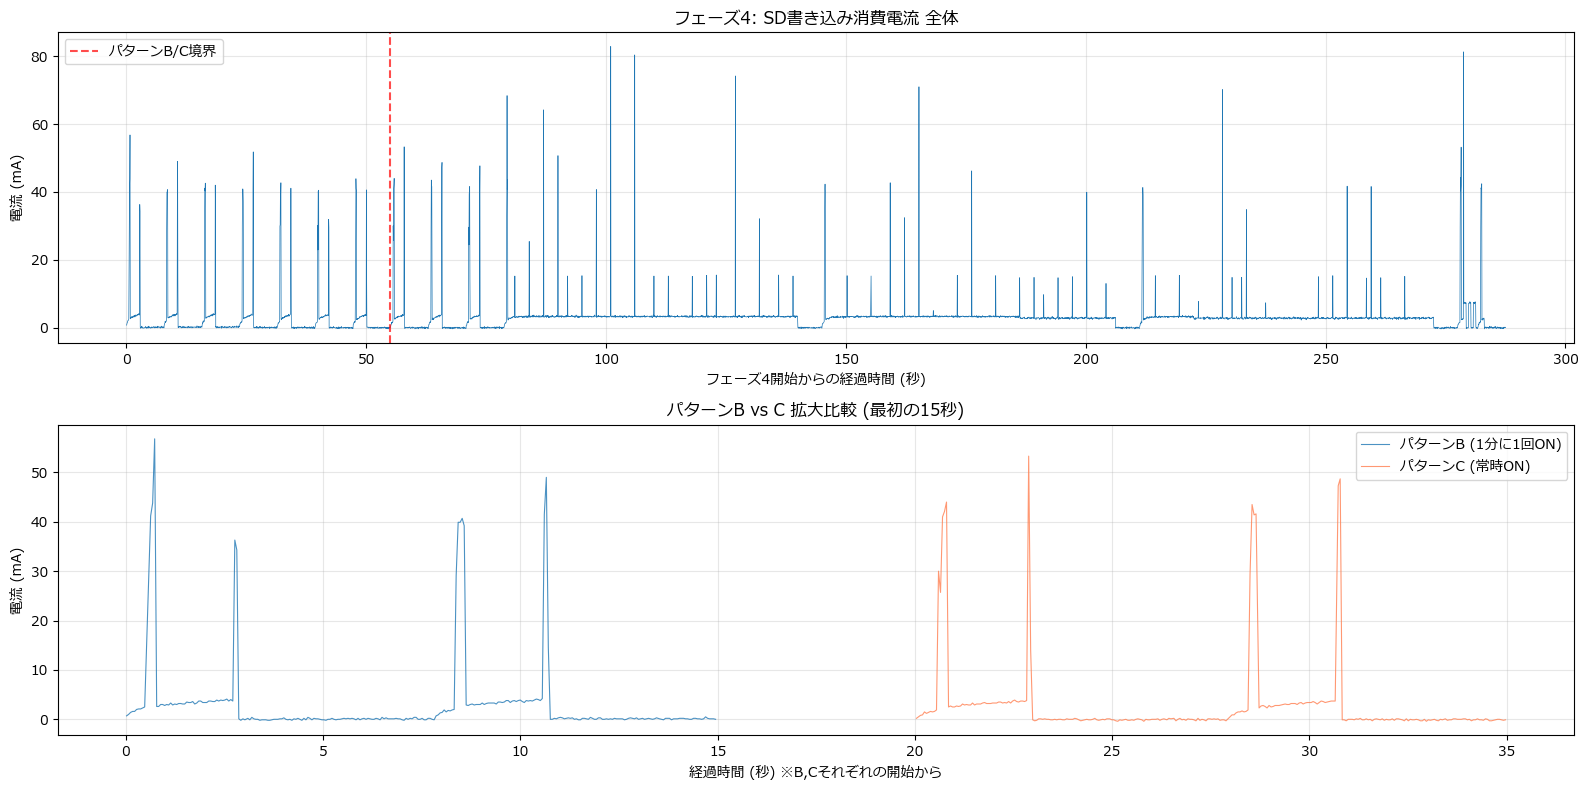

In [10]:
# ============================================================
# フェーズ4: SD区間の電流波形
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# 上段: フェーズ4全体
ax = axes[0]
ax.plot(p4_data['elapsed_s'] - p4_start, p4_data['Current (mA)'], linewidth=0.5)
ax.axvline(x=pb_end - p4_start, color='red', linestyle='--', alpha=0.7, label='パターンB/C境界')
ax.set_xlabel('フェーズ4開始からの経過時間 (秒)')
ax.set_ylabel('電流 (mA)')
ax.set_title('フェーズ4: SD書き込み消費電流 全体')
ax.legend()
ax.grid(True, alpha=0.3)

# 下段: パターンB/Cの拡大比較 (それぞれ最初の15秒)
ax = axes[1]

# パターンBの最初の15秒
pb_zoom = df[(df['elapsed_s'] >= p4_start) & (df['elapsed_s'] < p4_start + 15)]
ax.plot(pb_zoom['elapsed_s'] - p4_start, pb_zoom['Current (mA)'],
        linewidth=0.8, label='パターンB (1分に1回ON)', alpha=0.8)

# パターンCの最初の15秒
pc_zoom = df[(df['elapsed_s'] >= pb_end) & (df['elapsed_s'] < pb_end + 15)]
ax.plot(pc_zoom['elapsed_s'] - pb_end + 20, pc_zoom['Current (mA)'],  # 20秒オフセットで並べる
        linewidth=0.8, label='パターンC (常時ON)', alpha=0.8, color='coral')

ax.set_xlabel('経過時間 (秒) ※B,Cそれぞれの開始から')
ax.set_ylabel('電流 (mA)')
ax.set_title('パターンB vs C 拡大比較 (最初の15秒)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# サマリーテーブル
# ============================================================
print('=' * 60)
print('統合消費電流測定 サマリー v2 (Probe Request版)')
print('=' * 60)
print(f'WiFiベースライン (OFF区間): {wifi_baseline:.2f} mA')
print(f'カメラベースライン (OFF区間): {cam_baseline:.2f} mA')
print()

print('--- WiFiスキャン (ベースライン差し引き) ---')
print(summary_wifi.to_string(index=False))
print()

print('--- カメラ (ベースライン差し引き) ---')
print(f'平均電流: {df_camera["mean_mA"].mean():.1f} mA')
print(f'ピーク電流: {df_camera["peak_mA"].max():.1f} mA')
print(f'ON区間平均: {df_camera["duration_s"].mean():.1f} 秒')
print()

print('--- SD書き込み ---')
if len(pb_data) > 0:
    print(f'パターンB (1分1回ON) サイクル平均: {pb_data["Current (mA)"].mean():.2f} mA')
if len(pc_data) > 0:
    print(f'パターンC (常時ON)   サイクル平均: {pc_data["Current (mA)"].mean():.2f} mA')

統合消費電流測定 サマリー v2 (Probe Request版)
WiFiベースライン (OFF区間): 0.23 mA
カメラベースライン (OFF区間): 0.44 mA

--- WiFiスキャン (ベースライン差し引き) ---
 スキャン(ms)  回数   ON区間(秒)   平均電流(mA)  標準偏差(mA)    ピーク(mA)
     3000   5  6.646954 161.186903  1.292230 364.172323
     5000   5  8.764483 164.134040  1.417987 407.472323
    10000   5 13.883182 167.243934  1.587469 407.272323

--- カメラ (ベースライン差し引き) ---
平均電流: 135.2 mA
ピーク電流: 196.1 mA
ON区間平均: 62.7 秒

--- SD書き込み ---
パターンB (1分1回ON) サイクル平均: 2.58 mA
パターンC (常時ON)   サイクル平均: 3.21 mA


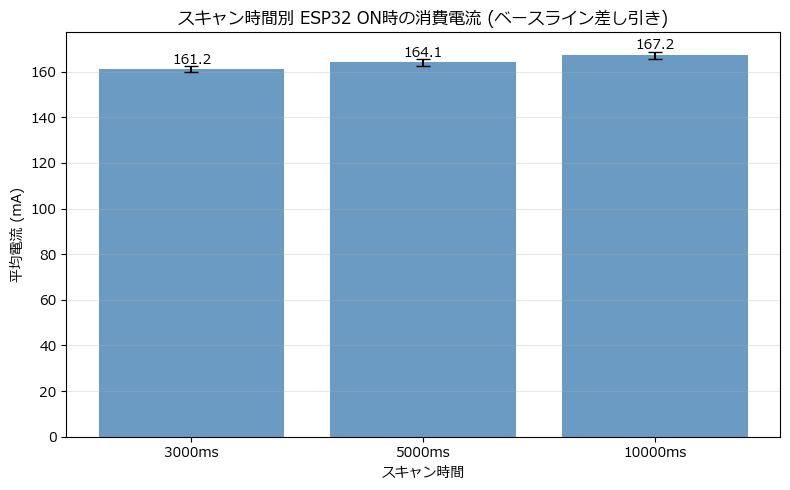

In [12]:
# ============================================================
# WiFiスキャン時間別 平均電流グラフ
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))

x = summary_wifi['スキャン(ms)'].values
y = summary_wifi['平均電流(mA)'].values
yerr = summary_wifi['標準偏差(mA)'].values

ax.bar(range(len(x)), y, yerr=yerr, capsize=5, color='steelblue', alpha=0.8)
ax.set_xticks(range(len(x)))
ax.set_xticklabels([f'{int(v)}ms' for v in x])
ax.set_xlabel('スキャン時間')
ax.set_ylabel('平均電流 (mA)')
ax.set_title('スキャン時間別 ESP32 ON時の消費電流 (ベースライン差し引き)')
ax.grid(True, alpha=0.3, axis='y')

for i, (v, e) in enumerate(zip(y, yerr)):
    ax.text(i, v + e + 1, f'{v:.1f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()